# Compare deconvolution with and without copy number correction

Levels to think about:
- 10kb
- Per gene
- Per gene promoter

Ideas:
- Copy number correction may affect nucleosome occupancy and promoter occupancy during S-phase, thus we'll have to think about the low hanging fruit to show how copy number correction improves the fit of the chromatin deconvolution.
- At a high-level it should be most clear at the 10kb window.
- Then on the gene-level. The gene level is a bit more challenging because of the different regulation dynamics at play, but it allows us to investigate dosage compensation-type ideas.



In [8]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [339]:
from glob import glob
# We can start by comparing the deconvolution results for chromosome 4 for each
# The 10kb total sum may be different.

chrom = 4
chr1_cc_data_directory = f'output/prototype_pipeline_subset/chromatin_deconvolution/deconvolution_data/chr{chrom}/'
chr1_no_cc_data_directory = f'output/prototype_pipeline_subset/chromatin_deconvolution_no_copy/deconvolution_data/chr{chrom}/'

windows = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')
windows = windows[windows.chr == chrom]
n = len(windows)

F_data_cc = np.zeros((n, 149, 26000))
F_data_no_cc = np.zeros((n, 149, 26000))

i = 0
for idx, row in windows.iterrows():
    
    try:
        data_no_cc = np.load(f"{chr1_no_cc_data_directory}/chr{row.chr}_{row.start}_{row.end+1}_F.npy")
        data_cc = np.load(f"{chr1_cc_data_directory}/chr{row.chr}_{row.start}_{row.end+1}_F.npy")
    except FileNotFoundError:
        print(f"Ending early at index: {i}")
        continue
    
    # Skip the last row, for ease of computation
    if i == len(windows)-1: break
        
    F_data_cc[i] = data_cc
    F_data_no_cc[i] = data_no_cc
    i += 1

Ending early at index: 153


In [340]:
chr1_cc_means = F_data_cc.mean(axis=2)
chr1_no_cc_means = F_data_no_cc.mean(axis=2)

In [507]:
window_idx = 54

imgs_cc = F_data_cc[window_idx].reshape((-1, 26, 1000))
imgs_no_cc = F_data_no_cc[window_idx].reshape((-1, 26, 1000))

t_indices = config1.t_indices()
b_indices = config1.b_indices()

# idx = t_indices[44]

# plt.figure(figsize=(18, 4))
# plt.subplot(2, 1, 1)
# plt.imshow(imgs_no_cc[idx], aspect='auto', cmap='magma_r', vmin=0, vmax=20, origin='lower')
# plt.title("No copy correction")
# plt.xticks([])

# plt.subplot(2, 1, 2)
# plt.imshow(imgs_cc[idx], aspect='auto', cmap='magma_r', vmin=0, vmax=20, origin='lower')
# plt.title("Copy corrected")
# plt.subplots_adjust(hspace=0.5)


In [508]:
from src.RealDataReplication import read_n_fr_b, read_no_copy_correction_n_fr_b

window_entry = windows.iloc[window_idx]
chrom = window_entry.chr
mnase_span = window_entry.start, window_entry.end

combined_dir = 'output/prototype_pipeline_subset/combined_replication'
combined_N = np.load(f'{combined_dir}/N.npy')
_, _, f_replication, b = read_n_fr_b(chrom, mnase_span, 1)

no_cc_N, no_cc_frep, no_cc_b = read_no_copy_correction_n_fr_b(H)

Loading single replication profile, 3/1/25
Trial N, need to use combined N curve


In [509]:
# Compute predicted with copy correction
H = np.concatenate([config1.H, config2.H])

N = combined_N
F = F_data_cc[window_idx]
F_no_cc = F_data_no_cc[window_idx]

predicted_G_copy_corrected = N@H@(np.multiply(F, f_replication[:, None]))*b
predicted_G_copy_corrected_removed = H@F
predicted_G_no_copy_corrected = H@F_no_cc


In [510]:
from src.RealDataReplication import read_g
window_10kb_g_curve_1 = read_g(chrom, mnase_span, 1)
window_10kb_g_curve_2 = read_g(chrom, mnase_span, 2)
raw_G_mean = np.concatenate([window_10kb_g_curve_1, window_10kb_g_curve_2])
raw_G_mean = raw_G_mean/raw_G_mean.mean()

Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run


(0.0, 2.0)

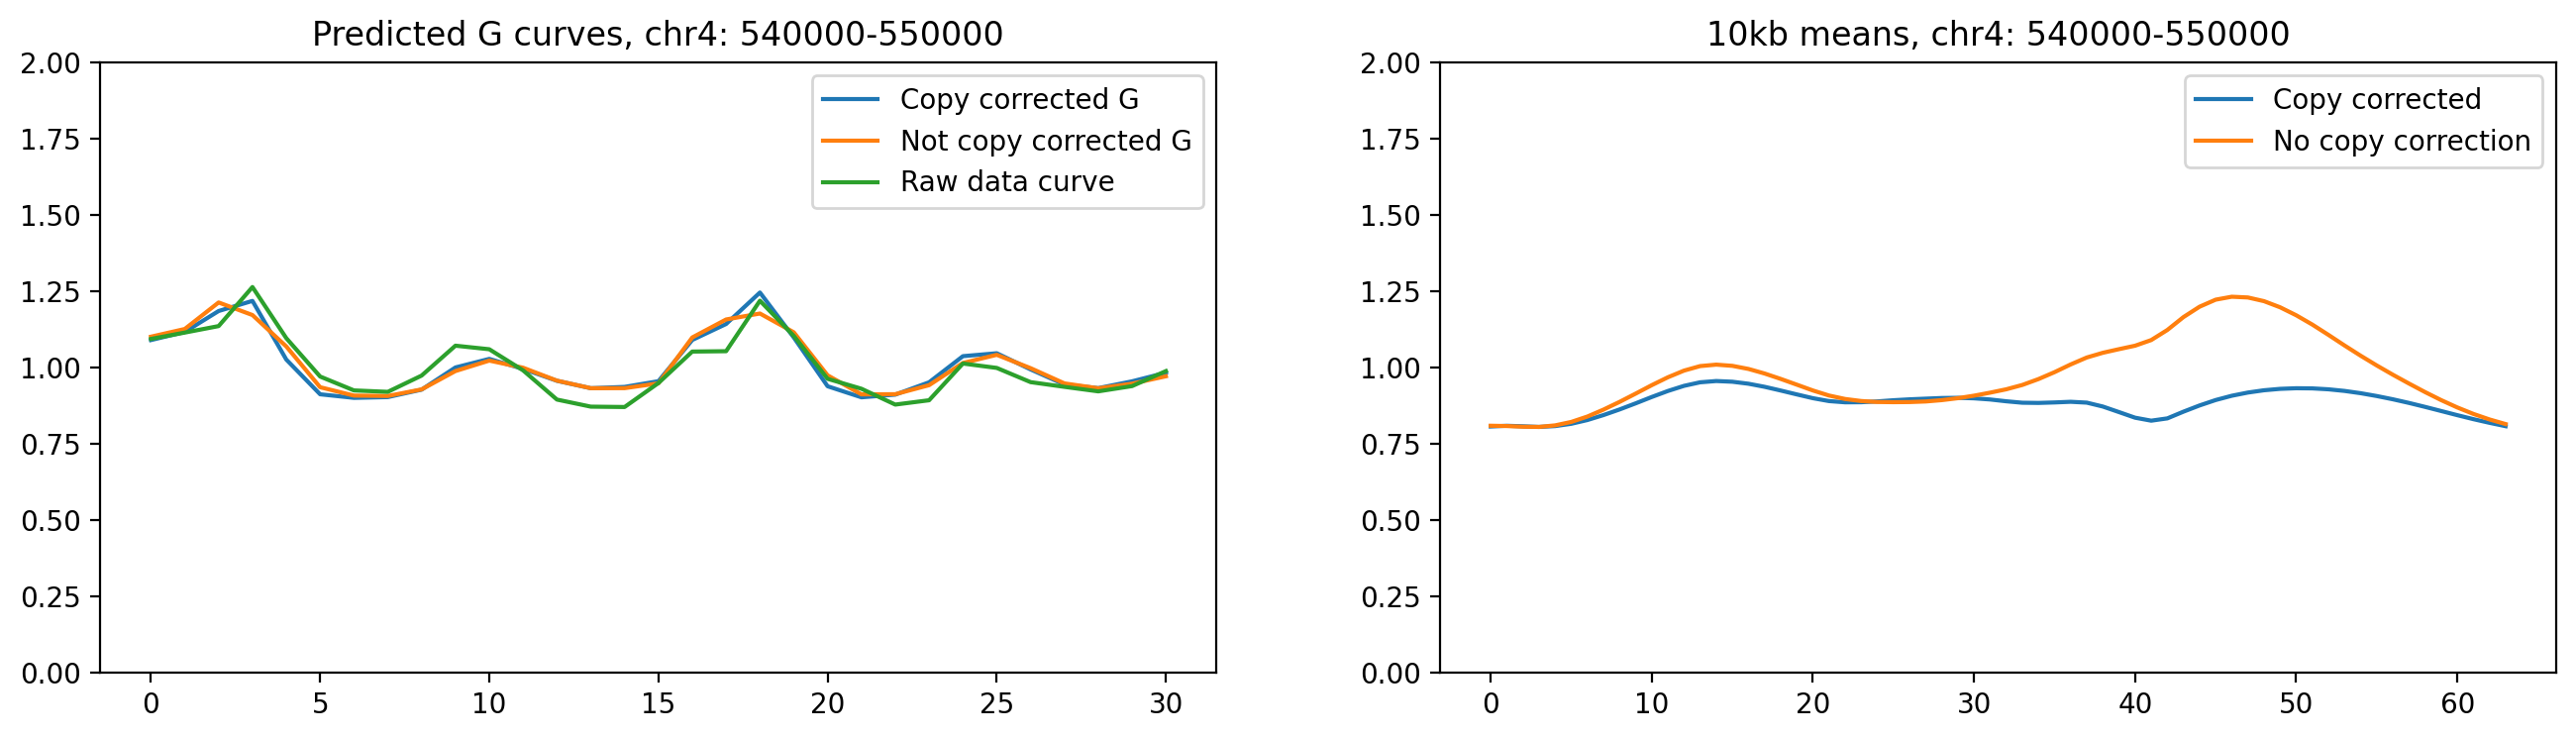

In [511]:
from src.config import load_default_chrom_configs

plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
plt.plot(predicted_G_copy_corrected.mean((1)), label="Copy corrected G")
plt.plot(predicted_G_no_copy_corrected.mean((1)), label="Not copy corrected G")
plt.plot(raw_G_mean, label="Raw data curve")
plt.ylim(0, 2)
plt.legend()
plt.title(f"Predicted G curves, chr{chrom}: {mnase_span[0]}-{mnase_span[1]}")

plt.subplot(1, 2, 2)
plt.plot(imgs_cc.mean((1, 2))[b_indices]*b, label="Copy corrected")
plt.plot(imgs_no_cc.mean((1, 2))[b_indices], label="No copy correction")
plt.legend()
plt.title(f"10kb means, chr{chrom}: {mnase_span[0]}-{mnase_span[1]}")
plt.ylim(0, 2)
# Maybe it will be more normal looking when N H and B are involved
# We would then expect the curve to be more leveled out for the predicted values of G...

(0.0, 2.0)

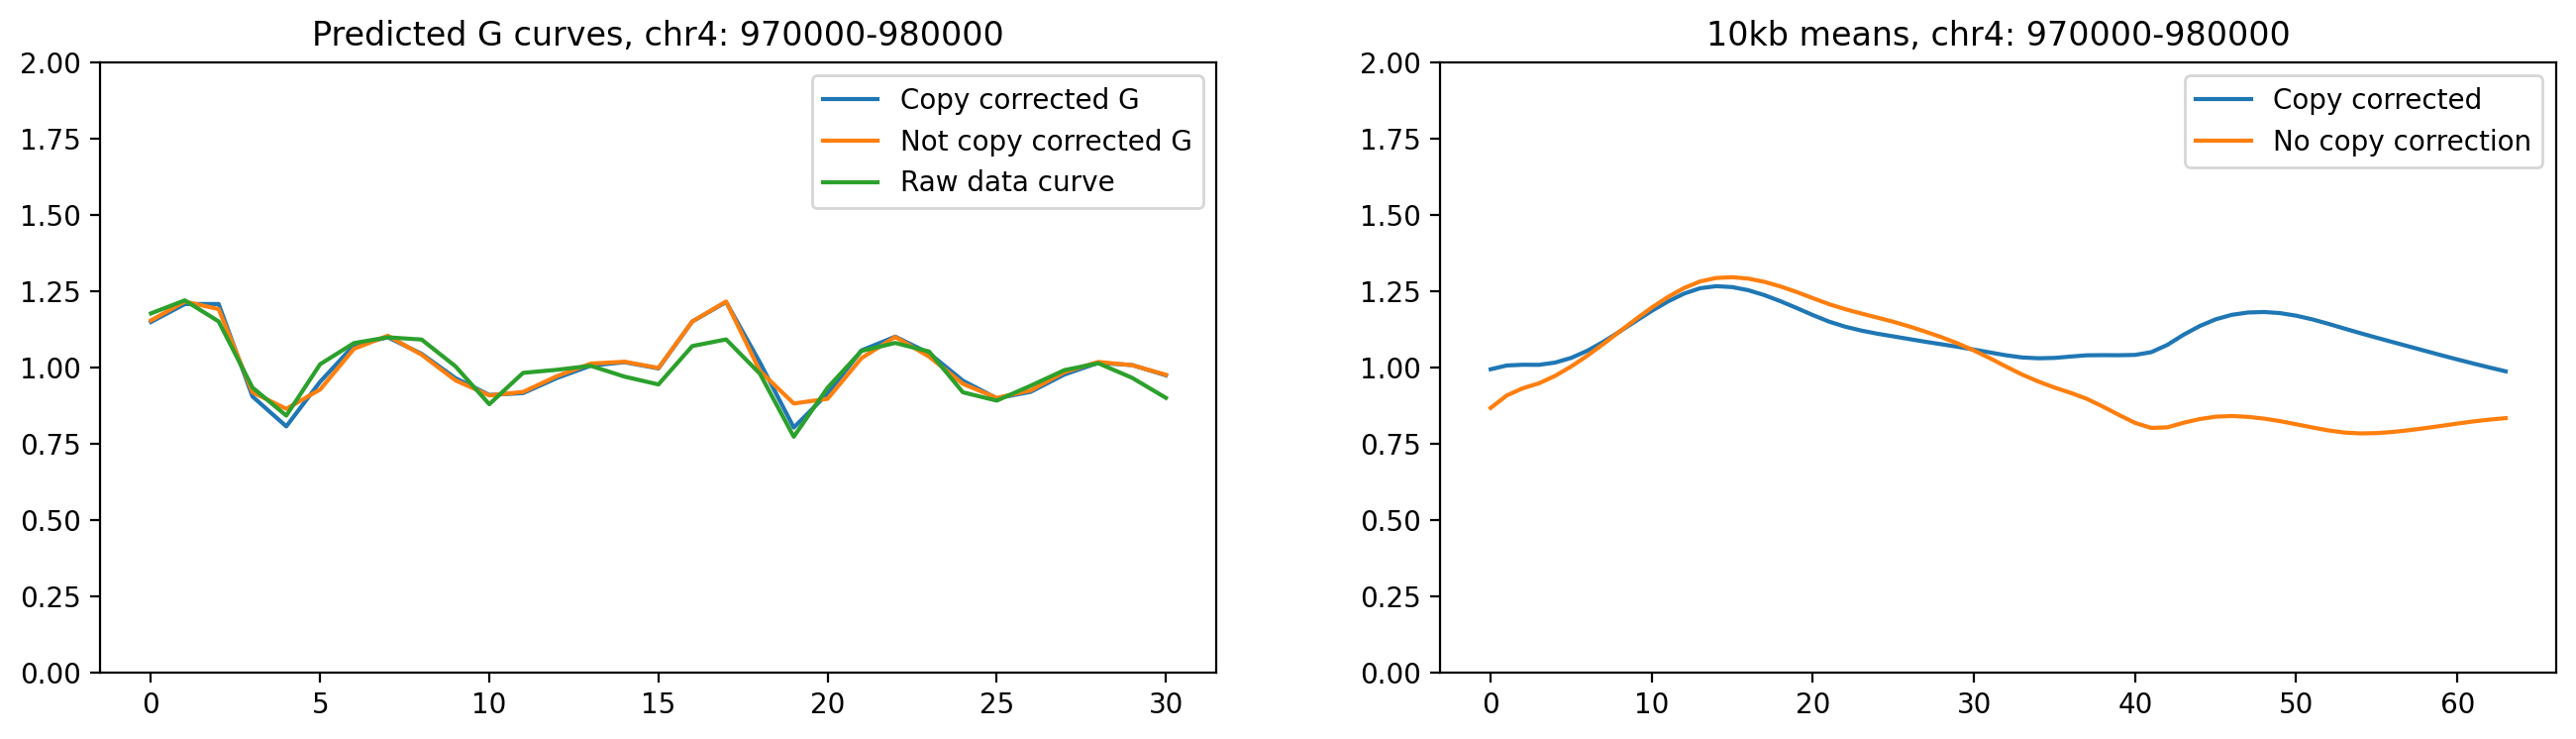

In [501]:
from src.config import load_default_chrom_configs

plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
plt.plot(predicted_G_copy_corrected.mean((1)), label="Copy corrected G")
plt.plot(predicted_G_no_copy_corrected.mean((1)), label="Not copy corrected G")
plt.plot(raw_G_mean, label="Raw data curve")
plt.ylim(0, 2)
plt.legend()
plt.title(f"Predicted G curves, chr{chrom}: {mnase_span[0]}-{mnase_span[1]}")

plt.subplot(1, 2, 2)
plt.plot(imgs_cc.mean((1, 2))[b_indices]*b, label="Copy corrected")
plt.plot(imgs_no_cc.mean((1, 2))[b_indices], label="No copy correction")
plt.legend()
plt.title(f"10kb means, chr{chrom}: {mnase_span[0]}-{mnase_span[1]}")
plt.ylim(0, 2)
# Maybe it will be more normal looking when N H and B are involved
# We would then expect the curve to be more leveled out for the predicted values of G...

In [502]:
from src.RealDataReplication import read_n_fr_b, read_no_copy_correction_n_fr_b

# Retrieve the replication timings for each window
# window_replication_times = windows.copy()
# for win_idx, window_entry in windows.iterrows():
#     chrom = window_entry.chr
#     mnase_span = window_entry.start, window_entry.end
#     _, _, f_replication, b = read_n_fr_b(chrom, mnase_span, 1, log=False)
#     window_replication_times.loc[win_idx, 'replication_index'] = f_replication.argmax()
# rep1_tp_lookup = config1.timepoints_df.set_index('Hpos')[['timepoint_start']]
# rep1_tps = [rep1_tp_lookup.loc[int(r_idx)].values[0] for r_idx in window_replication_times.replication_index]
# window_replication_times['replication_time'] = rep1_tps

window_replication_times.sort_values('replication_time')

,chr,start,end,replication_index,array_index,no_cc_ptr,cc_ptr,log2ratio_ptr,replication_time
194,4,560000,570000,126.0,56,1.136592,1.081204,-0.037893,38.120580
193,4,550000,560000,126.0,55,1.180699,1.129610,-0.034202,38.120580
192,4,540000,550000,126.0,54,1.170995,1.139744,-0.020918,38.120580
189,4,510000,520000,126.0,51,1.150643,1.115106,-0.024038,38.120580
188,4,500000,510000,126.0,50,1.150884,1.101612,-0.033434,38.120580
...,...,...,...,...,...,...,...,...,...
221,4,830000,840000,140.0,83,1.230010,1.121629,-0.071878,57.256556
198,4,600000,610000,140.0,60,1.164543,1.081597,-0.056372,57.256556
234,4,960000,970000,141.0,96,1.235432,1.093001,-0.094981,58.623412
235,4,970000,980000,141.0,97,1.243083,1.106512,-0.090627,58.623412


In [503]:
from src.peak_to_trough import compute_quantile_ptr_2d

cc_ptrs = compute_quantile_ptr_2d(F_data_cc.mean(2))
no_cc_ptrs = compute_quantile_ptr_2d(F_data_no_cc.mean(2))


In [504]:
i_indices = config1.i_indices()
t_indices = config1.t_indices()
b_indices = config1.b_indices()

t_cc_ptrs = compute_quantile_ptr_2d(F_data_cc.mean(2)[:, t_indices])
t_no_cc_ptrs = compute_quantile_ptr_2d(F_data_no_cc.mean(2)[:, t_indices])

b_cc_ptrs = compute_quantile_ptr_2d(F_data_cc.mean(2)[:, b_indices])
b_no_cc_ptrs = compute_quantile_ptr_2d(F_data_no_cc.mean(2)[:, b_indices])

i_cc_ptrs = compute_quantile_ptr_2d(F_data_cc.mean(2)[:, i_indices])
i_no_cc_ptrs = compute_quantile_ptr_2d(F_data_no_cc.mean(2)[:, i_indices])


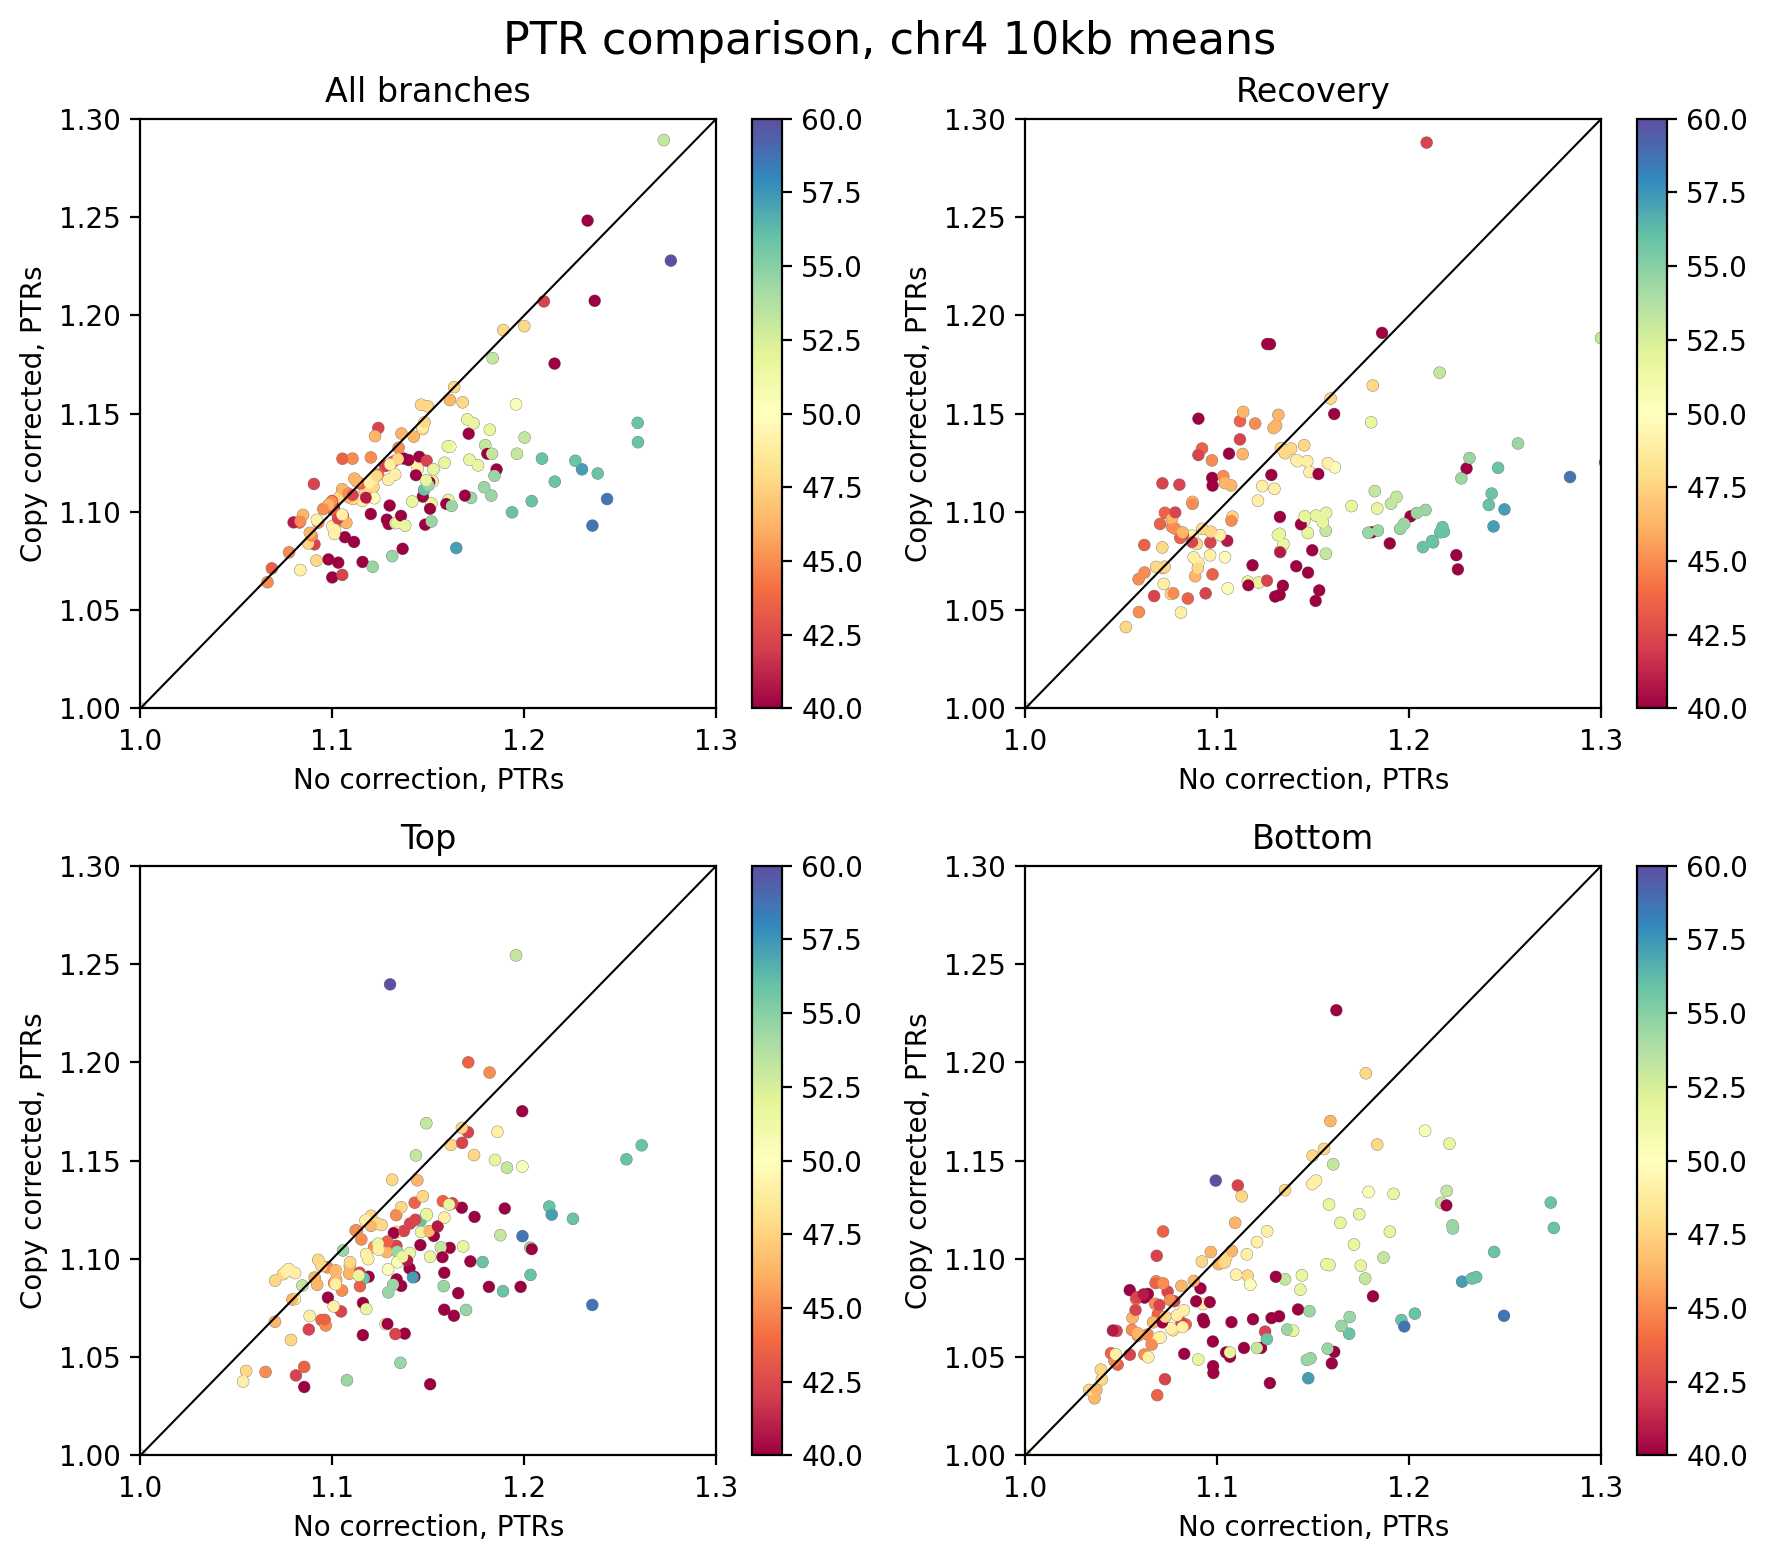

In [505]:
def plot_ptrs(no_cc_ptrs, cc_ptrs):
    plt.plot([0, 2], [0, 2], c='black', lw=0.75)
    plt.scatter(no_cc_ptrs, cc_ptrs, s=12, alpha=1, 
                edgecolor='gray', facecolor='none')
    plt.scatter(no_cc_ptrs, cc_ptrs, s=10, alpha=1, 
                c=window_replication_times.replication_time[:len(no_cc_ptrs)],
               cmap='Spectral', vmin=40, vmax=60)
    plt.xlim(1, 1.3)
    plt.ylim(1, 1.3)
    plt.xlabel("No correction, PTRs")
    plt.ylabel("Copy corrected, PTRs")
    plt.colorbar()

plt.figure(figsize=(9, 8))
plt.subplot(2, 2, 1)
plot_ptrs(no_cc_ptrs, cc_ptrs)
plt.title("All branches")

plt.subplot(2, 2, 2)
plot_ptrs(i_no_cc_ptrs, i_cc_ptrs)
plt.title("Recovery")

plt.subplot(2, 2, 3)
plot_ptrs(t_no_cc_ptrs, t_cc_ptrs)
plt.title("Top")

plt.subplot(2, 2, 4)
plot_ptrs(b_no_cc_ptrs, b_cc_ptrs)
plt.title("Bottom")

plt.suptitle(f"PTR comparison, chr{chrom} 10kb means", fontsize=16, y=0.97)
plt.tight_layout()

In [506]:
window_replication_times['array_index'] = np.arange(len(window_replication_times))
window_replication_times['no_cc_ptr'] = no_cc_ptrs
window_replication_times['cc_ptr'] = cc_ptrs
window_replication_times['log2ratio_ptr'] = np.log2((window_replication_times.cc_ptr+1) / 
                                   (window_replication_times.no_cc_ptr+1))